In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [2]:
df_sales = pd.read_csv(r"C:\Users\ASUS\Desktop\Desktop\Infotact Internship\Project 1 clean\Project-1-Omnichannel-retail-analysis-clean\cleaned_data\retail_sales_cleaned.csv")
df_inv = pd.read_csv(r"C:\Users\ASUS\Desktop\Desktop\Infotact Internship\Project 1 clean\Project-1-Omnichannel-retail-analysis-clean\cleaned_data\retail_inventory_cleaned.csv")

In [3]:
df_inv.isna().sum()
df_inv.info()

<class 'pandas.DataFrame'>
RangeIndex: 284755 entries, 0 to 284754
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   start_date                284755 non-null  str    
 1   end_date                  284755 non-null  str    
 2   stock_status              284755 non-null  str    
 3   supplier                  284755 non-null  str    
 4   product_no                284755 non-null  str    
 5   product_description       284755 non-null  str    
 6   product_division          284755 non-null  str    
 7   product_category          284755 non-null  str    
 8   product_subcategory       284755 non-null  str    
 9   product_segment           284755 non-null  str    
 10  store                     284755 non-null  str    
 11  store_type                284755 non-null  str    
 12  sales_channel             284755 non-null  str    
 13  qty_on_hand               284755 non-null  int64  
 14 

In [4]:
df_inv.head()

,start_date,end_date,stock_status,supplier,product_no,product_description,product_division,product_category,product_subcategory,product_segment,store,store_type,sales_channel,qty_on_hand,stocks_selling_amount,cost_of_stocks,stock_unit_selling_price,stock_unit_cost_price
0,2025-08-07,2025-10-18,Full Price,Vendor 0255,PROD-159369,PROD-103395 SEG-500461 Scholar Footwear Canvas...,Scholar Footwear,Scholar Footwear Canvas Styles,Scholar Footwear Canvas Styles Drifter,SEG-500461 Scholar Footwear Canvas Styles Drifter,STR-1010,Retail Storefront,Channel Alpha,1,55.0,24.75,55.0,24.75
1,2026-02-15,2026-02-15,Full Price,Vendor 0010,PROD-180713,PROD-190644 SEG-520887 Femme Footwear Court Ca...,Femme Footwear,Femme Footwear Court Casual,Femme Footwear Court Casual Trident,SEG-520887 Femme Footwear Court Casual Trident,STR-1082,Retail Storefront,Channel Alpha,1,130.0,59.73,130.0,59.73
2,2026-01-08,2026-02-15,Full Price,Vendor 0166,PROD-169474,PROD-153439 SEG-512518 Femme Footwear Court Ca...,Femme Footwear,Femme Footwear Court Casual,Femme Footwear Court Casual Zephyr,SEG-512518 Femme Footwear Court Casual Zephyr,STR-1105,Retail Storefront,Channel Alpha,1,120.0,60.44,120.0,60.44
3,2025-12-23,2026-02-15,Full Price,Vendor 0106,PROD-170976,PROD-122029 SEG-504463 Junior Apparel Cozy Pul...,Junior Apparel,Junior Apparel Cozy Pullovers,Junior Apparel Cozy Pullovers Varied,SEG-504463 Junior Apparel Cozy Pullovers Varied,STR-1157,Retail Storefront,Channel Alpha,3,150.0,52.50,50.0,17.50
4,2026-02-10,9999-12-31,Full Price,Vendor 0134,PROD-183525,PROD-111954 SEG-502325 Scholar Footwear Modern...,Scholar Footwear,Scholar Footwear Modern Legend,Scholar Footwear Modern Legend Summit,SEG-502325 Scholar Footwear Modern Legend Summit,STR-1253,Retail Storefront,Channel Alpha,4,360.0,182.16,90.0,45.54


In [5]:
df_sales.head()

,transaction_date,sales_type,is_return,supplier,product_no,product_description,product_division,product_category,product_subcategory,product_segment,store,sales_channel,qty_sold,sales_amount,cogs,number_of_transactions
0,2025-09-01,Full Price,0,Vendor 0169,PROD-139867,PROD-100449 SEG-500065 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,SEG-500065 Scholar Footwear Trailblazer Equili...,STR-1006,Channel Alpha,1.0,115.00,52.31,1
1,2025-09-07,Full Price,0,Vendor 0166,PROD-100449,PROD-100825 SEG-500112 Heritage Footwear Fligh...,Femme Footwear,Femme Footwear Flight Classic,Femme Footwear Flight Classic Varied,SEG-500112 Heritage Footwear Flight Classic Ze...,STR-1198,Channel Alpha,1.0,115.00,58.47,1
2,2025-08-06,Promo,0,Vendor 0169,PROD-153623,PROD-148813 SEG-511388 Scholar Footwear Trailb...,Scholar Footwear,Scholar Footwear Trailblazer,Scholar Footwear Trailblazer Equilibrium,SEG-511388 Scholar Footwear Trailblazer Equili...,STR-1157,Channel Alpha,1.0,79.99,43.76,1
3,2025-08-31,Full Price,0,Vendor 0246,PROD-140876,PROD-100419 SEG-500063 Scholar Footwear Boot C...,Scholar Footwear,Scholar Footwear Boot Collection,Scholar Footwear Boot Collection Woodland,SEG-500063 Scholar Footwear Boot Collection Wo...,STR-1234,Channel Alpha,1.0,110.00,50.60,1
4,2026-03-22,Full Price,0,Vendor 0169,PROD-166113,PROD-149345 SEG-511444 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Equilibrium,SEG-511444 Femme Footwear Trailblazer Equilibrium,STR-1157,Channel Alpha,1.0,160.00,77.95,1


In [6]:
df_sales['transaction_date'] = pd.to_datetime( df_sales['transaction_date'], format='mixed', dayfirst=True)
df_inv['start_date'] = pd.to_datetime(df_inv['start_date'], )
df_inv['end_date'] = pd.to_datetime(df_inv['end_date'], errors='coerce')

### Important Time Columns

In [7]:
df_sales['year'] = df_sales['transaction_date'].dt.year
df_sales['month'] = df_sales['transaction_date'].dt.month
df_sales['month_name'] = df_sales['transaction_date'].dt.month_name()

df_sales['day'] = df_sales['transaction_date'].dt.day

df_sales['weekday'] = df_sales['transaction_date'].dt.day_name()

df_sales['weekend_flag'] = np.where(
    df_sales['weekday'].isin(['Saturday', 'Sunday']),
    'Weekend',
    'Weekday'
)

### Creating Business KPIs

#### Store managers care about:

- Revenue
- Profit
- Fast moving products
- Store performance
- Weekend sales
- Inventory availability

In [8]:
#Create Profit Column
df_sales['profit'] = df_sales['sales_amount'] - df_sales['cogs']

#### Daily Revenue Trend

In [9]:
daily_sales = df_sales.groupby('transaction_date').agg({
    'sales_amount':'sum',
    'profit':'sum',
    'qty_sold':'sum'
}).reset_index()
print(daily_sales)

    transaction_date  sales_amount    profit  qty_sold
0         2025-01-06      22565.33  10892.08     244.0
1         2025-01-07      19023.62   8714.13     217.0
2         2025-01-08      55369.09  25282.07     624.0
3         2025-01-09      48997.97  23184.77     543.0
4         2025-01-10      17933.63   7299.19     202.0
..               ...           ...       ...       ...
321       2026-11-04      36806.51  16259.06     435.0
322       2026-12-01      10685.27   3945.82     143.0
323       2026-12-02      45015.85  20638.41     405.0
324       2026-12-03      29851.97  11273.57     385.0
325       2026-12-04      21345.70   9489.11     247.0

[326 rows x 4 columns]


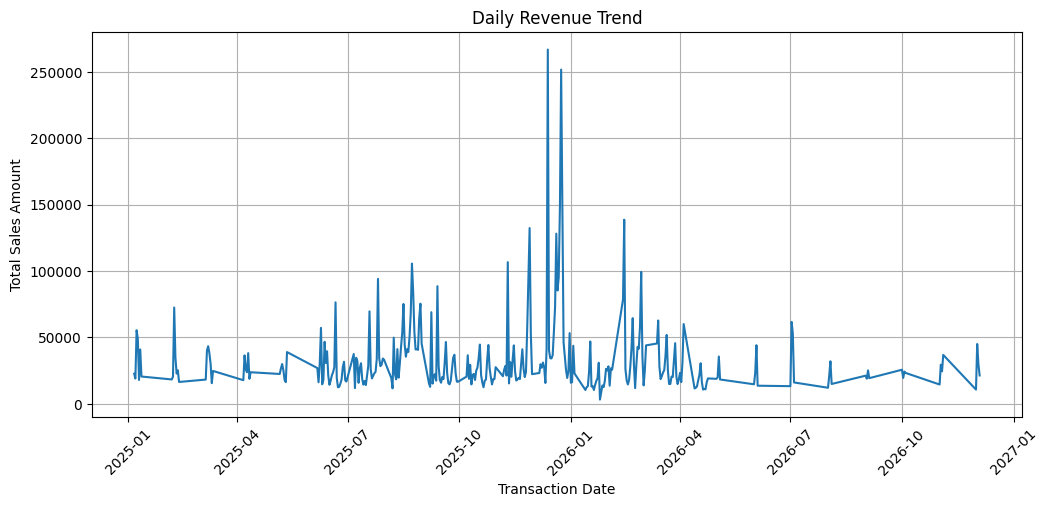

In [10]:
plt.figure(figsize=(12, 5))
plt.plot( daily_sales['transaction_date'], daily_sales['sales_amount'])
plt.title("Daily Revenue Trend")
plt.xlabel("Transaction Date")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#### Weekday vs Weekend Performance

In [11]:
weekend_analysis = df_sales.groupby('weekend_flag').agg({
    'sales_amount':'sum',
    'profit':'sum',
    'qty_sold':'sum'
}).reset_index()
print(weekend_analysis)

#Revenue Comparison
total = 6661650.38 + 3820459.87

weekday_percent = (6661650.38 / total) * 100
weekend_percent = (3820459.87 / total) * 100

print("Weekday % :", round(weekday_percent,2))
print("Weekend % :", round(weekend_percent,2))


  weekend_flag  sales_amount        profit  qty_sold
0      Weekday    6661650.38  2.928978e+06   75720.0
1      Weekend    3820459.87  1.705381e+06   41275.0
Weekday % : 63.55
Weekend % : 36.45


- The analysis shows that weekday sales contribute significantly more revenue than weekend sales. Approximately 63% of total revenue is generated during weekdays, indicating stronger customer purchasing activity on working days. Weekend sales still contribute a substantial portion of revenue but remain lower in comparison. This insight can help store managers optimize staffing, inventory allocation, and promotional campaigns based on customer traffic patterns.
---
#### Store manager can:

- Keep higher staff availability on weekdays
- Maintain more inventory during weekdays
- Run weekend promotions to increase traffic
- Identify if certain categories perform better on weekends

#### This can be misleading because:

- Weekdays = 5 days
- Weekend = 2 days

So naturally weekdays may have higher totals.

 so we calculate,  
#### Average sales per weekday vs per weekend day

In [12]:
daily_type_sales = df_sales.groupby(
    ['transaction_date', 'weekend_flag']
)['sales_amount'].sum().reset_index()

print("daily_type_sales : ")
print(daily_type_sales)
print()

avg_sales = daily_type_sales.groupby(
    'weekend_flag'
)['sales_amount'].mean().reset_index()

print('Average sales per weekday vs per weekend day ')
print(avg_sales)

daily_type_sales : 
    transaction_date weekend_flag  sales_amount
0         2025-01-06      Weekday      22565.33
1         2025-01-07      Weekday      19023.62
2         2025-01-08      Weekday      55369.09
3         2025-01-09      Weekday      48997.97
4         2025-01-10      Weekday      17933.63
..               ...          ...           ...
321       2026-11-04      Weekday      36806.51
322       2026-12-01      Weekday      10685.27
323       2026-12-02      Weekday      45015.85
324       2026-12-03      Weekday      29851.97
325       2026-12-04      Weekday      21345.70

[326 rows x 3 columns]

Average sales per weekday vs per weekend day 
  weekend_flag  sales_amount
0      Weekday  28714.010259
1      Weekend  40643.190106


#### so in summery : 
- Total weekday revenue > total weekend revenue
- Average revenue per weekend day > average revenue per weekday

#### This means:

- Customers spend more per day on weekends.

#### Product Category Trends

In [13]:
category_sales = df_sales.groupby('product_category').agg({
    'sales_amount':'sum',
    'profit':'sum',
    'qty_sold':'sum'
}).sort_values(by='sales_amount', ascending=False)

print(category_sales)

                                  sales_amount       profit  qty_sold
product_category                                                     
Scholar Footwear Retro Legend       1920958.56  905344.3400   12569.0
Scholar Footwear Trailblazer        1909759.99  927715.3700   20584.0
Femme Footwear Trailblazer          1238790.65  436689.0400   12325.0
Scholar Footwear Modern Legend      1062646.92  405024.2800   10731.0
Scholar Footwear Flight Classic      767298.33  354519.3300    8926.0
Scholar Footwear Court Casual        702385.90  281848.1800    9530.0
Scholar Footwear Boot Collection     660152.85  358274.6600    6049.0
Femme Footwear Court Casual          647820.37  240117.8001    7279.0
Femme Footwear Boot Collection       304630.62  154503.4900    2321.0
Femme Footwear Flight Classic        303495.26  140888.6700    2728.0
Femme Footwear Retro Legend          177667.32   85156.4200     849.0
Scholar Footwear Hardcourt           106883.73   41612.7700     702.0
Junior Apparel Cozy 

#### Fast-Moving Inventory
Fast-moving inventory means:
- Products that sell quickly and frequently.

Store managers care because:

- these products need frequent restocking
- stockouts hurt revenue
- these products indicate customer demand

##### BEST METRIC : "qty_sold" , "number_of_transactions"

In [14]:
fast_moving = df_sales.groupby('product_category').agg({
    'qty_sold':'sum',
    'sales_amount':'sum',
    'number_of_transactions':'sum'
})

In [15]:
fast_moving = fast_moving.sort_values(
    by='qty_sold',
    ascending=False
)
fast_moving

,qty_sold,sales_amount,number_of_transactions
product_category,,,
Scholar Footwear Trailblazer,20584.0,1909759.99,23117
Scholar Footwear Retro Legend,12569.0,1920958.56,13801
Femme Footwear Trailblazer,12325.0,1238790.65,14536
Scholar Footwear Modern Legend,10731.0,1062646.92,12207
Scholar Footwear Court Casual,9530.0,702385.90,10762
Scholar Footwear Flight Classic,8926.0,767298.33,9846
Femme Footwear Court Casual,7279.0,647820.37,8368
Scholar Footwear Boot Collection,6049.0,660152.85,6875
Junior Apparel Crew Tees,4078.0,86652.57,4273


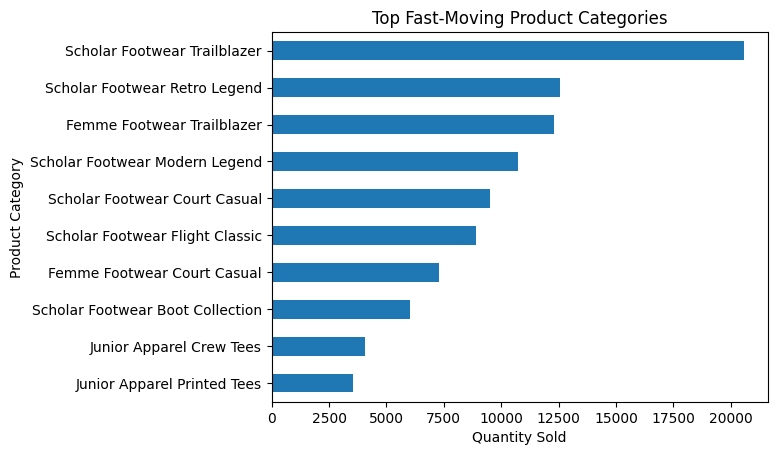

In [16]:
top_fast_moving = fast_moving.head(10)

top_fast_moving['qty_sold'].plot(kind='barh')
plt.xlabel("Quantity Sold")
plt.ylabel("Product Category")
plt.title("Top Fast-Moving Product Categories")
plt.gca().invert_yaxis()
plt.show()

In [17]:
df_inv.columns


Index(['start_date', 'end_date', 'stock_status', 'supplier', 'product_no',
       'product_description', 'product_division', 'product_category',
       'product_subcategory', 'product_segment', 'store', 'store_type',
       'sales_channel', 'qty_on_hand', 'stocks_selling_amount',
       'cost_of_stocks', 'stock_unit_selling_price', 'stock_unit_cost_price'],
      dtype='str')

In [18]:
#sales amount group by sales type 
grp = df_sales.groupby('sales_type')['sales_amount'].sum()
grp

print(grp['Clearance'] + grp['Full Price'])

8913865.42


In [41]:
df_inv['start_date_month'] = df_inv['start_date'].dt.month
df_inv['end_date_month'] = df_inv['end_date'].dt.month

df_inv_sorted = df_inv.sort_values(by="start_date")
df_inv_sorted[df_inv_sorted['product_category'] == 'Femme Footwear Trailblazer']


,start_date,end_date,stock_status,supplier,product_no,product_description,product_division,product_category,product_subcategory,product_segment,store,store_type,sales_channel,qty_on_hand,stocks_selling_amount,cost_of_stocks,stock_unit_selling_price,stock_unit_cost_price,start_date_month,end_date_month
284754,2025-06-01,2025-06-27,Full Price,Vendor 0166,PROD-124435,PROD-154330 SEG-512711 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-512711 Femme Footwear Trailblazer Zephyr,STR-1305,Retail Storefront,Channel Alpha,2,340.0,160.16,170.0,80.080,6,6
169957,2025-06-01,2025-06-19,Full Price,Vendor 0166,PROD-158661,PROD-174352 SEG-517028 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-517028 Femme Footwear Trailblazer Zephyr,STR-1105,Retail Storefront,Channel Alpha,2,340.0,160.16,170.0,80.080,6,6
34443,2025-06-01,2025-11-22,Full Price,Vendor 0166,PROD-124439,PROD-154324 SEG-512711 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-512711 Femme Footwear Trailblazer Zephyr,STR-1229,Retail Storefront,Channel Alpha,2,340.0,160.24,170.0,80.120,6,11
170134,2025-06-01,2025-07-31,Full Price,Vendor 0166,PROD-124435,PROD-154330 SEG-512711 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-512711 Femme Footwear Trailblazer Zephyr,STR-1074,Retail Storefront,Channel Alpha,2,340.0,159.81,170.0,79.905,6,7
170171,2025-06-01,2025-06-17,Full Price,Vendor 0166,PROD-158660,PROD-174353 SEG-517028 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-517028 Femme Footwear Trailblazer Zephyr,STR-1038,Retail Storefront,Channel Alpha,2,340.0,160.16,170.0,80.080,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240267,2026-04-24,9999-12-31,Full Price,Vendor 0166,PROD-124432,PROD-154327 SEG-512711 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-512711 Femme Footwear Trailblazer Zephyr,STR-1353,Retail Storefront,Channel Alpha,3,510.0,253.59,170.0,84.530,4,12
240266,2026-04-24,9999-12-31,Full Price,Vendor 0166,PROD-124436,PROD-154331 SEG-512711 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-512711 Femme Footwear Trailblazer Zephyr,STR-1074,Retail Storefront,Channel Alpha,1,170.0,86.13,170.0,86.130,4,12
240263,2026-04-24,9999-12-31,Full Price,Vendor 0166,PROD-124432,PROD-154327 SEG-512711 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-512711 Femme Footwear Trailblazer Zephyr,STR-1107,Retail Storefront,Channel Alpha,1,170.0,86.02,170.0,86.020,4,12
240262,2026-04-24,9999-12-31,Full Price,Vendor 0166,PROD-124432,PROD-154327 SEG-512711 Femme Footwear Trailbla...,Femme Footwear,Femme Footwear Trailblazer,Femme Footwear Trailblazer Zephyr,SEG-512711 Femme Footwear Trailblazer Zephyr,STR-1075,Retail Storefront,Channel Alpha,1,170.0,86.02,170.0,86.020,4,12


In [29]:
current = df_inv[df_inv['end_date'] == '31-12-9999']
print(current)
current['qty_on_hand'].sum()

       start_date   end_date     stock_status     supplier   product_no  \
4      2026-02-10 9999-12-31       Full Price  Vendor 0134  PROD-183525   
30     2025-10-07 9999-12-31       Full Price  Vendor 0262  PROD-176445   
35     2025-11-17 9999-12-31       Full Price  Vendor 0169  PROD-166155   
36     2025-11-17 9999-12-31       Full Price  Vendor 0169  PROD-166156   
37     2025-11-17 9999-12-31       Full Price  Vendor 0169  PROD-166157   
...           ...        ...              ...          ...          ...   
284731 2026-04-20 9999-12-31  Markdown Tier 1  Vendor 0037  PROD-165076   
284732 2026-04-20 9999-12-31       Full Price  Vendor 0010  PROD-165569   
284733 2026-04-20 9999-12-31       Full Price  Vendor 0010  PROD-165579   
284747 2026-04-15 9999-12-31       Full Price  Vendor 0169  PROD-168845   
284748 2026-04-15 9999-12-31       Full Price  Vendor 0258  PROD-184466   

                                      product_description  product_division  \
4       PROD-111954 

np.int64(37187)

### product having dead stock
- dead stock means - product is unsold from too many days or too much less sale. 

In [48]:
current_date = datetime.datetime(2026, 6, 3)
df_inv['days_in_inventory'] = (current_date - df_inv['start_date']).dt.days

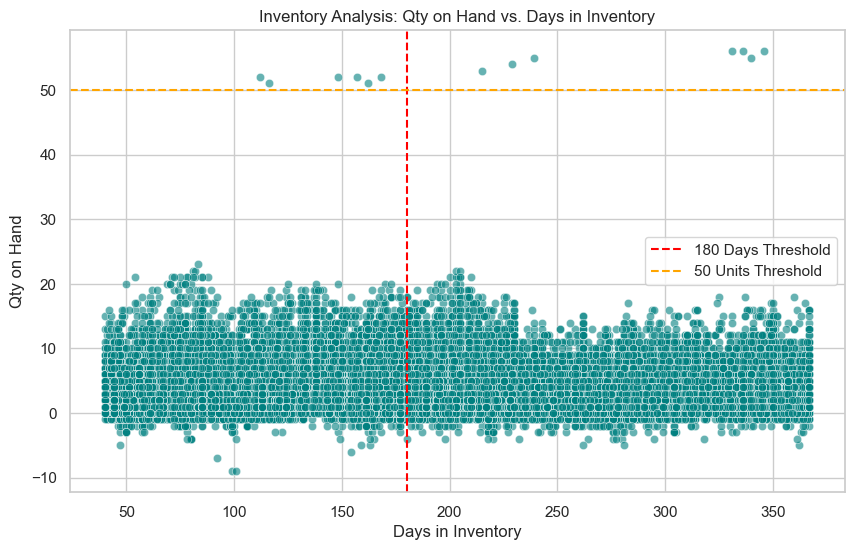

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_inv, x='days_in_inventory', y='qty_on_hand', alpha=0.6, color='teal')
plt.axvline(x=180, color='red', linestyle='--', label='180 Days Threshold')
plt.axhline(y=50, color='orange', linestyle='--', label='50 Units Threshold')
plt.title('Inventory Analysis: Qty on Hand vs. Days in Inventory')
plt.xlabel('Days in Inventory')
plt.ylabel('Qty on Hand')
plt.legend()
plt.show()

In [66]:
df_inv[(df_inv['days_in_inventory'] > 180) & (df_inv['qty_on_hand'] > 50)]['product_category'].unique()

<ArrowStringArray>
['Femme Footwear Court Casual']
Length: 1, dtype: str

In [71]:
df_sales.columns

Index(['transaction_date', 'sales_type', 'is_return', 'supplier', 'product_no',
       'product_description', 'product_division', 'product_category',
       'product_subcategory', 'product_segment', 'store', 'sales_channel',
       'qty_sold', 'sales_amount', 'cogs', 'number_of_transactions', 'year',
       'month', 'month_name', 'day', 'weekday', 'weekend_flag', 'profit'],
      dtype='str')

In [73]:
inv_summary = df_inv.groupby('supplier').agg(
    Avg_Days_in_Inventory=('days_in_inventory', 'mean'),
    Total_Qty_on_Hand=('qty_on_hand', 'sum')
).reset_index()

sales_summary = df_sales.groupby('supplier').agg(
    Total_Transactions=('is_return', 'count'),
    Total_Returns=('is_return', 'sum'),
    Total_Sales_Amount=('sales_amount', 'sum'),
    Total_Cogs=('cogs', 'sum')
).reset_index()


print(inv_summary)
print(sales_summary)

       supplier  Avg_Days_in_Inventory  Total_Qty_on_Hand
0   Vendor 0008             236.699065               1738
1   Vendor 0010             222.016072              37971
2   Vendor 0025             201.827586                723
3   Vendor 0027             209.003623                868
4   Vendor 0037             187.773028               4691
5   Vendor 0039             101.528428                536
6   Vendor 0042             206.850806                409
7   Vendor 0052             239.569980                848
8   Vendor 0054             255.498427              10826
9   Vendor 0064             204.040083              26290
10  Vendor 0082             225.038760                258
11  Vendor 0084             200.379310                377
12  Vendor 0094             212.638215               3088
13  Vendor 0106             194.462563              44683
14  Vendor 0126             238.714715               2885
15  Vendor 0134             219.047002             106190
16  Vendor 014

In [96]:
vendor_scorecard = pd.merge(sales_summary, inv_summary, on='supplier', how='inner')
vendor_scorecard



# Filter out very low-volume suppliers to maintain data consistency
# Let's consider suppliers with more than 100 sales transactions
reliable_scorecard = vendor_scorecard[vendor_scorecard['Total_Transactions'] > 100]
print(reliable_scorecard.columns)
print(reliable_scorecard)
# Round metrics for readability

reliable_scorecard['Return Rate'] = reliable_scorecard['Return Rate'].round(2)
# The math happening in the background:
# ((Total Sales - Total COGS) / Total Sales) * 100
print(sales_summary.columns)
sales_summary['Gross Profit Margin'] = ((sales_summary['Total_Sales_Amount'] - sales_summary['Total_Cogs']) / sales_summary['Total_Sales_Amount']) * 100
reliable_scorecard['Gross Profit Margin'] = reliable_scorecard['Gross Profit Margin'].round(2)
reliable_scorecard['Avg_Days_in_Inventory'] = reliable_scorecard['Avg_Days_in_Inventory'].round(1)


# ==========================================
# STEP 4: PRINT RESULTS TO DETECT PATTERNS
# ==========================================
print("--- TOP 5 SUPPLIERS WITH LOWEST RETURN RATES (HIGHEST QUALITY) ---")
print(reliable_scorecard.sort_values(by='Return Rate %', ascending=True).head(5)[
    ['supplier', 'Return Rate %', 'Gross Profit Margin %', 'Avg_Days_in_Inventory']
].to_string(index=False))

print("\n--- TOP 5 SUPPLIERS WITH HIGHEST RETURN RATES (QUALITY ISSUES) ---")
print(reliable_scorecard.sort_values(by='Return Rate %', ascending=False).head(5)[
    ['supplier', 'Return Rate %', 'Gross Profit Margin %', 'Avg_Days_in_Inventory']
].to_string(index=False))

Index(['supplier', 'Total_Transactions', 'Total_Returns', 'Total_Sales_Amount',
       'Total_Cogs', 'Return Rate %', 'Return Rate', 'Gross Profit Margin %',
       'Gross Profit Margin', 'Avg_Days_in_Inventory', 'Total_Qty_on_Hand'],
      dtype='str')
       supplier  Total_Transactions  Total_Returns  Total_Sales_Amount  \
0   Vendor 0008                 530             23            45562.33   
1   Vendor 0010                7488            474           490924.49   
4   Vendor 0037                1161             46            28432.74   
5   Vendor 0039                 164             12             6250.25   
6   Vendor 0042                 192              7             3421.90   
7   Vendor 0052                 236             12            13340.49   
8   Vendor 0054                1928             68            77121.67   
9   Vendor 0064                4278            434           423710.82   
12  Vendor 0094                 408              4             3687.75   
13  Ve